[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Sat Aug 15 13:35:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [4]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

100% 5.35M/5.35M [00:00<00:00, 127MB/s]
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 104k/104k [00:00<00:00, 119MB/s]
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 49.8ms
Speed: 4.9ms preprocess, 49.8ms inference, 191.3ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

In [5]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpeg', width=600)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict/dog.jpeg'

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 60.1ms
Speed: 3.9ms preprocess, 60.1ms inference, 924.2ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

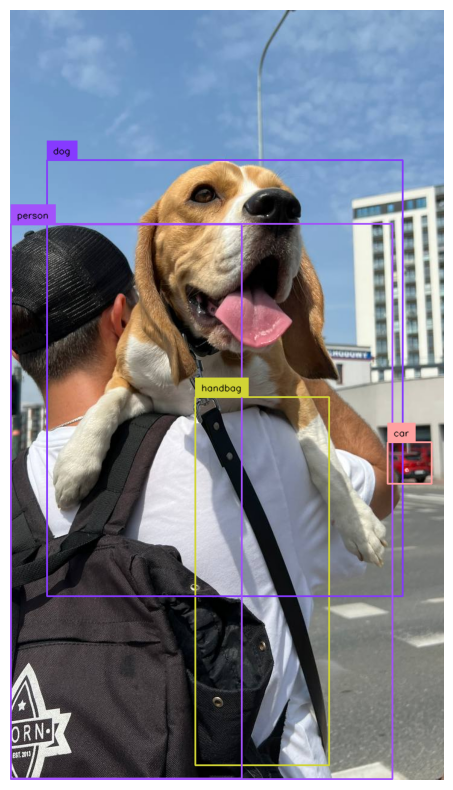

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [7]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("gadjiiavov-n4n8k")
project = workspace.project("fire-fhsxx")
version = project.version(2)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fire-2 in yolov11:: 100%|██████████| 16924/16924 [00:02<00:00, 7677.85it/s] 


## Custom Training

In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 210MB/s]
New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/fire-2/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=Non

### Lưu mô hình vào Google Drive để sử dụng lại

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bây giờ, bạn có thể tạo một thư mục trong Google Drive của mình để lưu mô hình và sao chép tệp `best.pt` vào đó. Ví dụ, để lưu vào một thư mục tên là `yolov11_models`:

In [11]:
import os

# Đường dẫn đến thư mục chứa trọng số mô hình đã huấn luyện
source_model_path = os.path.join(HOME, 'runs', 'detect', 'train', 'weights', 'best.pt')

# Đường dẫn đến thư mục đích trong Google Drive của bạn
destination_folder = '/content/drive/MyDrive/yolov11_models'

# Tạo thư mục đích nếu nó chưa tồn tại
os.makedirs(destination_folder, exist_ok=True)

# Sao chép mô hình
!cp {source_model_path} {destination_folder}/

print(f"Mô hình đã được lưu vào: {destination_folder}/best.pt")

Mô hình đã được lưu vào: /content/drive/MyDrive/yolov11_models/best.pt


Các con số hiện tại trong quá trình huấn luyện (đang ở Epoch 4, 62% hoàn thành) có ý nghĩa như sau:

*   **Epoch 4/10**: Đây là Epoch thứ 4 trên tổng số 10 Epoch được cấu hình để huấn luyện mô hình. Quá trình huấn luyện đang chạy được khoảng 62% của Epoch này.
*   **GPU_mem 4.47G**: Lượng bộ nhớ GPU hiện đang được sử dụng là 4.47 Gigabyte. Đây là chỉ số quan trọng để theo dõi việc sử dụng tài nguyên.
*   **box_loss 1.792**: Giá trị mất mát hộp giới hạn (bounding box loss) hiện tại là 1.792. Giá trị này cho biết mô hình đang dự đoán các hộp giới hạn chính xác đến mức nào. Mục tiêu là giá trị này sẽ giảm dần theo thời gian.
*   **cls_loss 1.632**: Giá trị mất mát phân loại lớp (classification loss) hiện tại là 1.632. Giá trị này cho biết mô hình đang phân loại các đối tượng chính xác đến mức nào. Tương tự, mục tiêu là giá trị này sẽ giảm dần.
*   **dfl_loss 1.814**: Giá trị mất mát DFL (Distributed Focal Loss) hiện tại là 1.814. Đây là một thành phần mất mát cụ thể của YOLOv11, cũng nên giảm dần.
*   **Instances 27**: Số lượng các trường hợp (đối tượng) trong lô (batch) dữ liệu hiện tại đang được xử lý là 27.
*   **Size 640**: Kích thước hình ảnh (pixel) mà mô hình đang huấn luyện hoặc đánh giá trong lô hiện tại là 640x640.

Vì Epoch 4 vẫn đang chạy, các giá trị này là tạm thời trong quá trình huấn luyện của Epoch đó. Sau khi Epoch 4 hoàn tất, bạn sẽ thấy các chỉ số đánh giá `Box(P)`, `R`, `mAP50`, và `mAP50-95` được tính toán trên tập dữ liệu xác thực (validation dataset).

Hãy cùng giải thích các chỉ số được hiển thị trong quá trình huấn luyện:

*   **Epoch**: Đây là số lần toàn bộ tập dữ liệu huấn luyện đã được truyền qua mạng nơ-ron.
*   **GPU_mem**: Lượng bộ nhớ GPU (đơn vị GB) đang được sử dụng trong quá trình huấn luyện.
*   **box_loss**: Đây là thành phần của hàm mất mát (loss function) liên quan đến độ chính xác của hộp giới hạn (bounding box) dự đoán. Giá trị thấp hơn cho thấy các hộp giới hạn được dự đoán chính xác hơn.
*   **cls_loss**: Thành phần của hàm mất mát liên quan đến độ chính xác của phân loại lớp (class classification). Giá trị thấp hơn cho thấy mô hình phân loại các đối tượng chính xác hơn.
*   **dfl_loss**: Loss cho Distributed Focal Loss, một thành phần đặc biệt trong YOLOv11 giúp tối ưu hóa việc phân bố các đặc trưng (features) cho nhiệm vụ phát hiện đối tượng.
*   **Instances**: Số lượng các phiên bản đối tượng được phát hiện hoặc được chú thích trong lô (batch) hiện tại hoặc trong tập dữ liệu đánh giá.
*   **Size**: Kích thước hình ảnh (pixel) được sử dụng để huấn luyện hoặc đánh giá trong lô hiện tại.

Sau mỗi epoch, mô hình cũng được đánh giá trên tập dữ liệu xác thực (validation dataset), và bạn sẽ thấy các chỉ số sau:

*   **Class**: Lớp đối tượng cụ thể đang được đánh giá.
*   **Images**: Số lượng hình ảnh trong tập dữ liệu xác thực.
*   **Box(P)** (Precision): Độ chính xác. Tỷ lệ số lượng dự đoán đúng là dương trong tổng số dự đoán là dương. Điều này cho biết mô hình của bạn tốt đến mức nào trong việc tránh sai lầm khi dự đoán một đối tượng.
*   **R** (Recall): Độ thu hồi. Tỷ lệ số lượng dự đoán đúng là dương trong tổng số các đối tượng dương thực sự. Điều này cho biết mô hình của bạn tốt đến mức nào trong việc tìm ra tất cả các đối tượng có liên quan.
*   **mAP50** (mean Average Precision at IOU 0.50): Độ chính xác trung bình (mAP) được tính khi ngưỡng Intersection Over Union (IOU) là 0.50. Đây là một chỉ số phổ biến để đánh giá hiệu suất của mô hình phát hiện đối tượng, càng cao càng tốt.
*   **mAP50-95** (mean Average Precision across different IOU thresholds from 0.50 to 0.95): Độ chính xác trung bình được tính trên nhiều ngưỡng IOU khác nhau (từ 0.50 đến 0.95). Đây là một chỉ số toàn diện hơn, vì nó đánh giá hiệu suất của mô hình ở nhiều mức độ chồng lấn của hộp giới hạn. Càng cao càng tốt.

Nhìn chung, để đánh giá một mô hình tốt, bạn muốn thấy `box_loss`, `cls_loss`, `dfl_loss` giảm dần theo thời gian, trong khi `P`, `R`, `mAP50`, và `mAP50-95` tăng dần.

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [12]:
!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1786801363.e775d4853465.3122.0  train_batch2.jpg
F1_curve.png					    val_batch0_labels.jpg
labels_correlogram.jpg				    val_batch0_pred.jpg
labels.jpg					    val_batch1_labels.jpg
P_curve.png					    val_batch1_pred.jpg
PR_curve.png					    val_batch2_labels.jpg
R_curve.png					    val_batch2_pred.jpg
results.csv					    weights


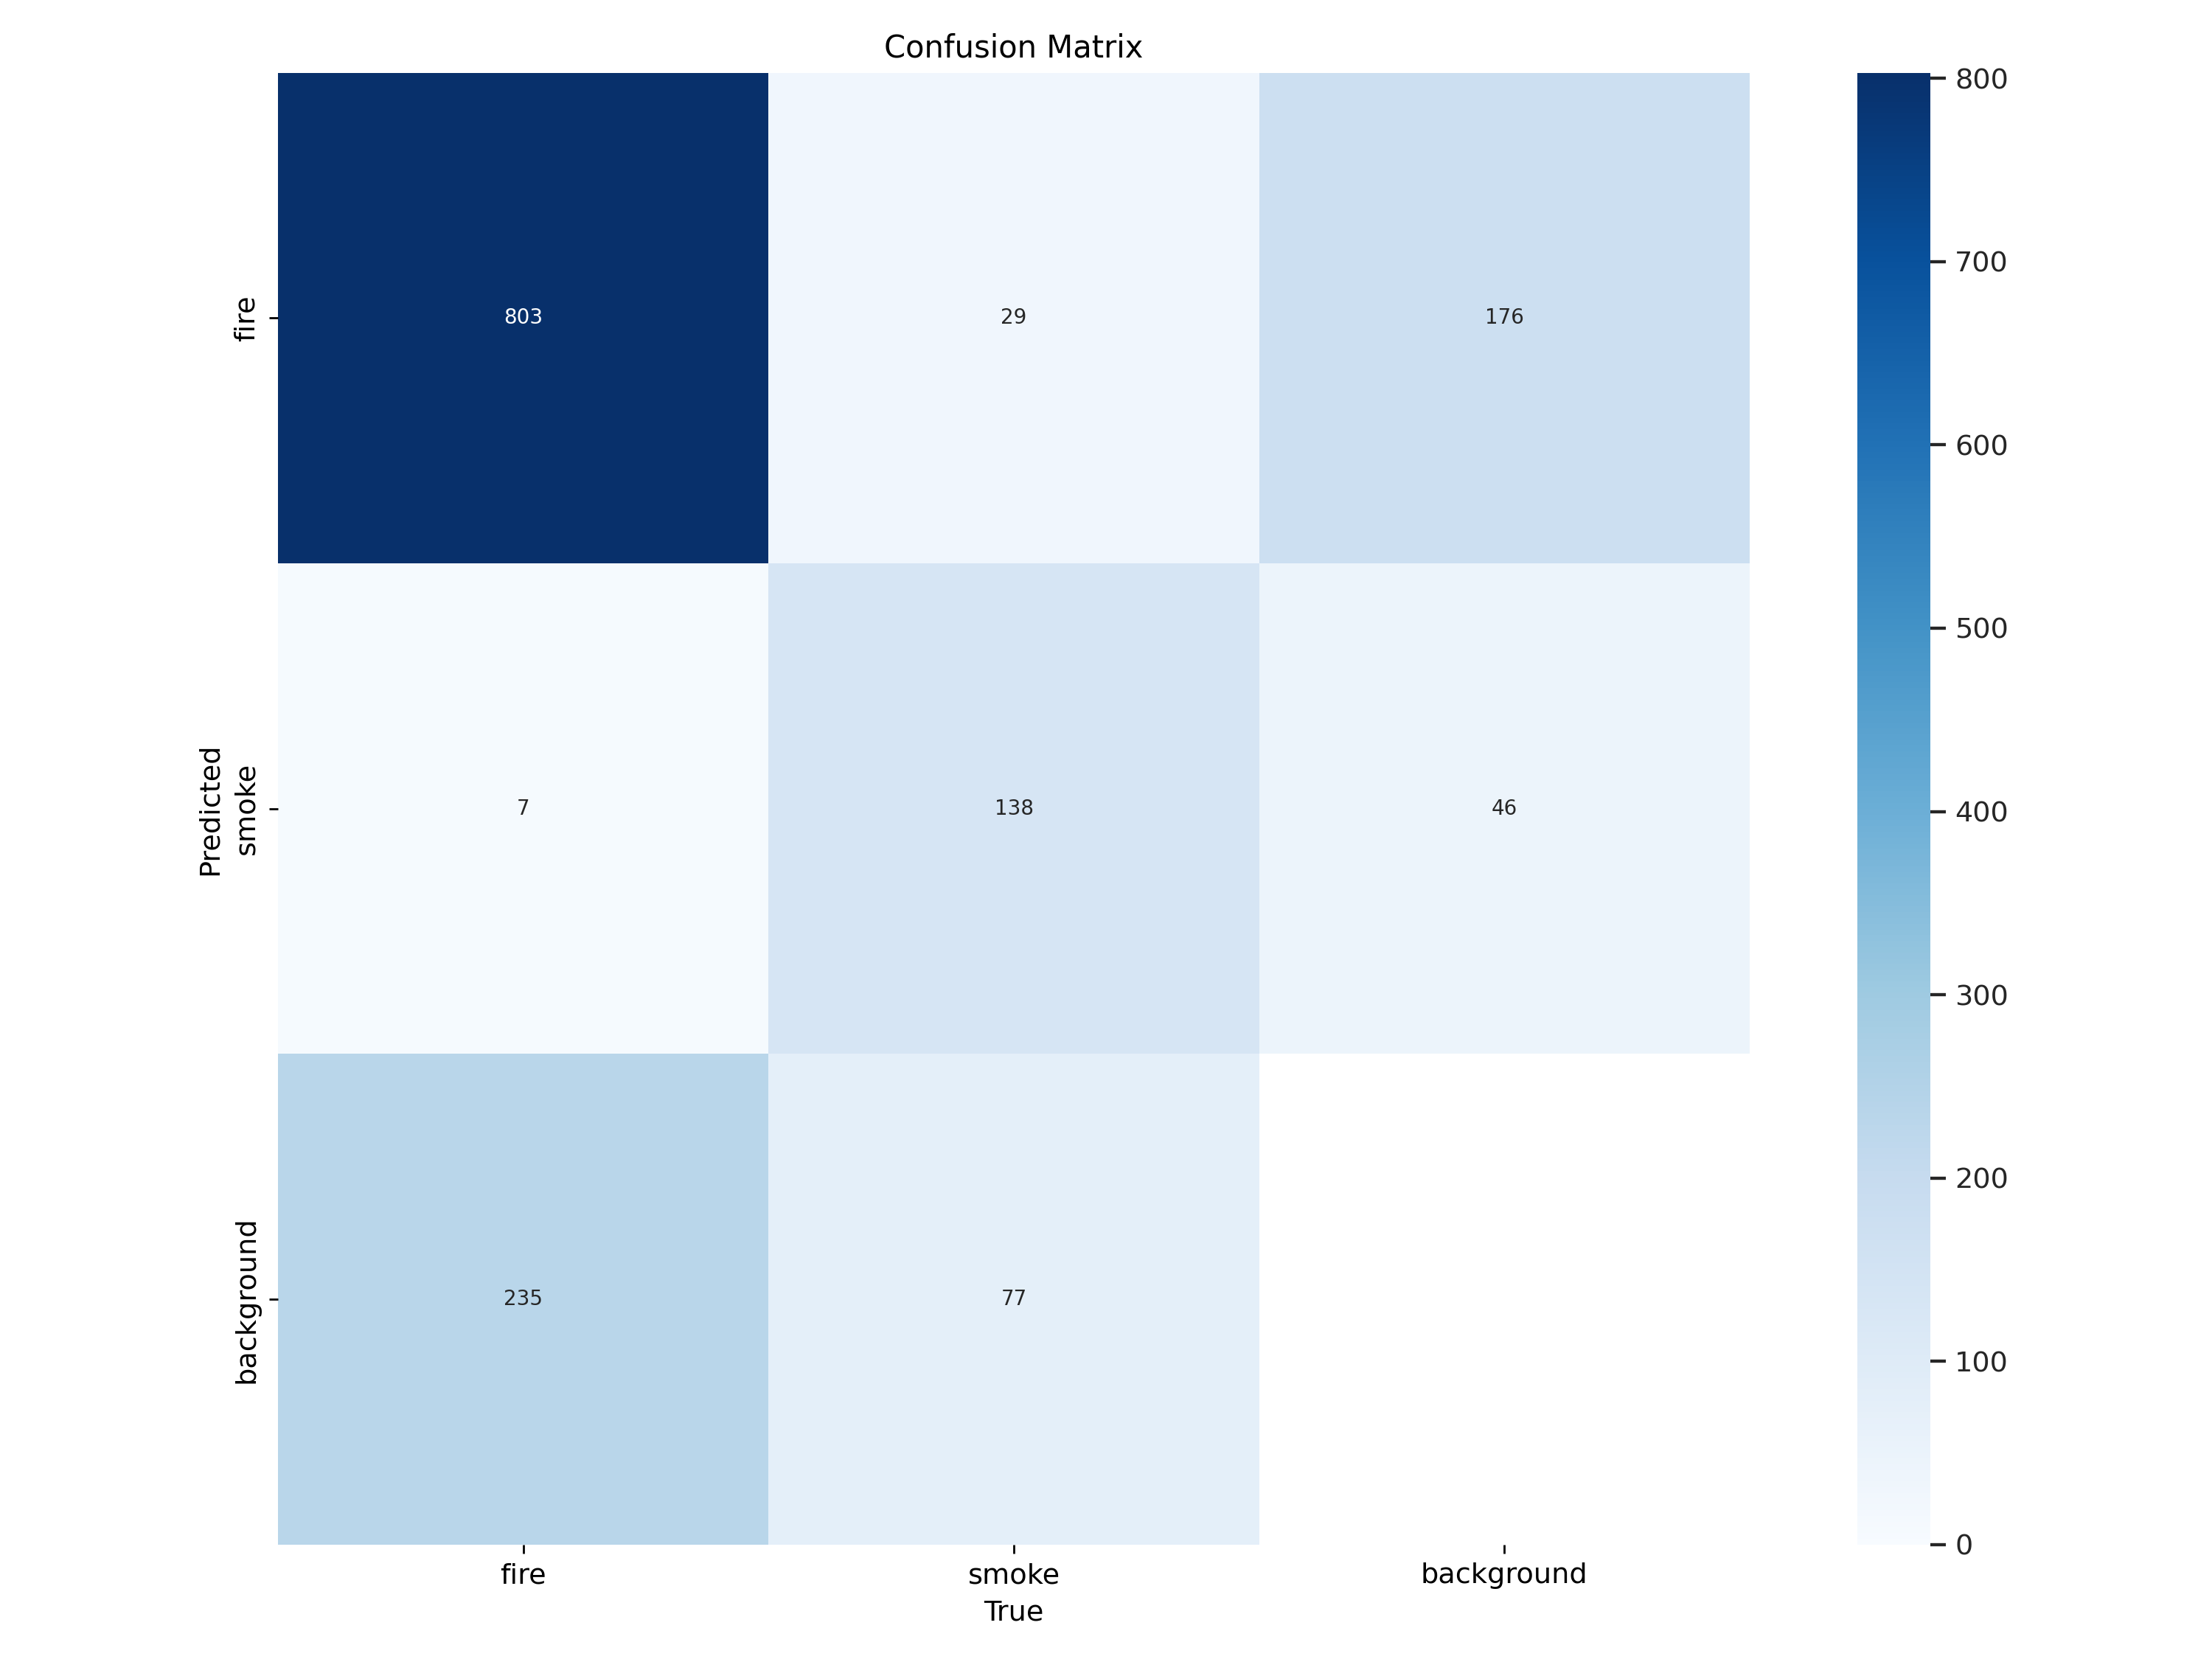

In [13]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

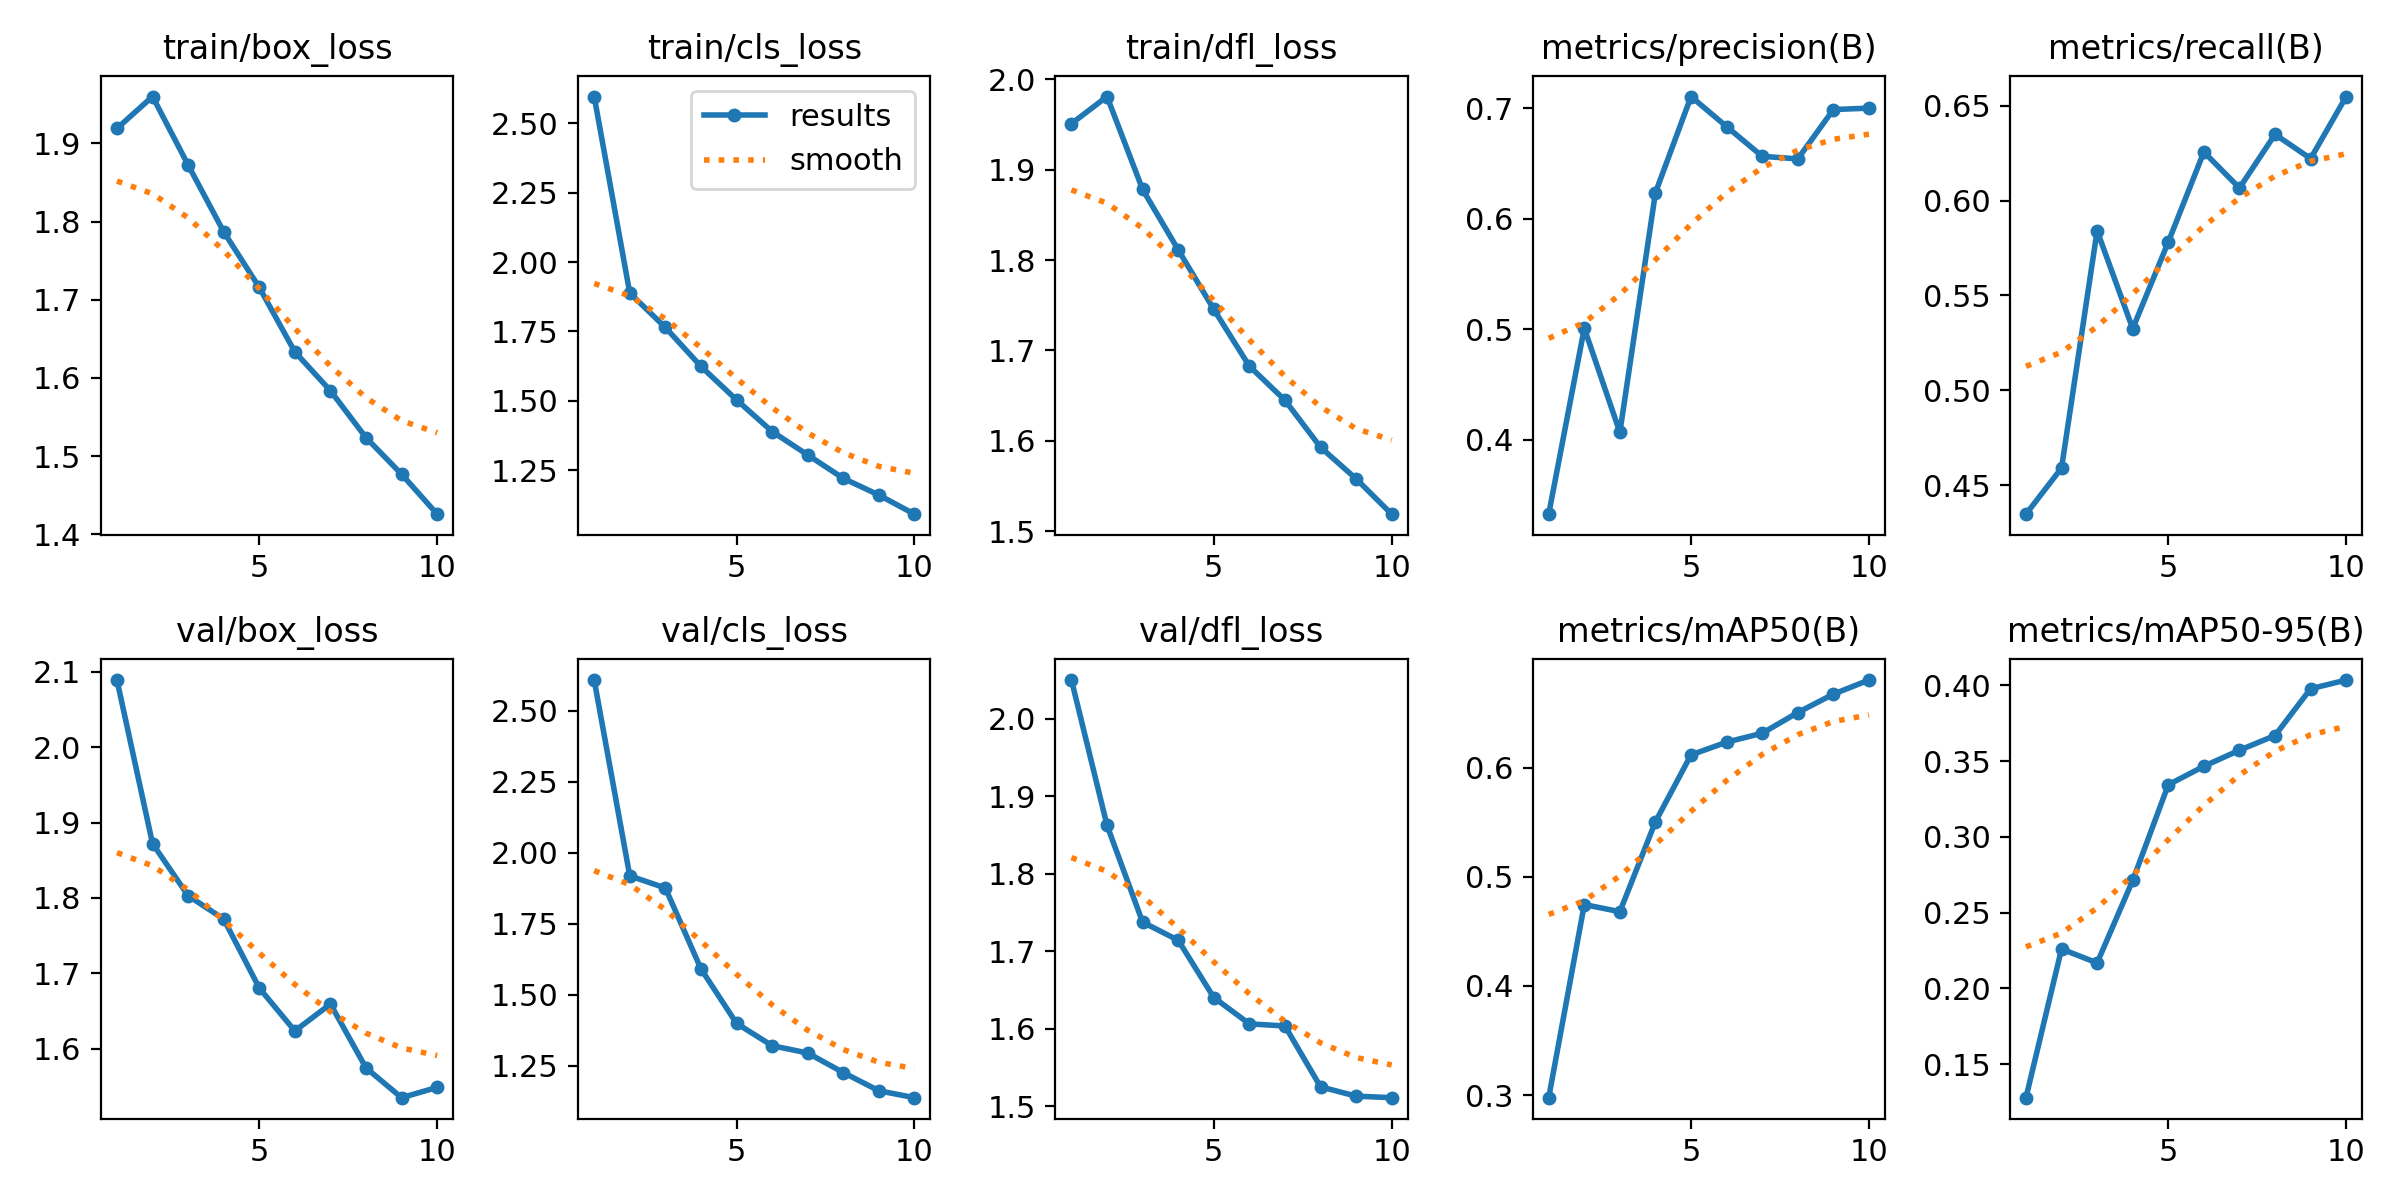

In [14]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

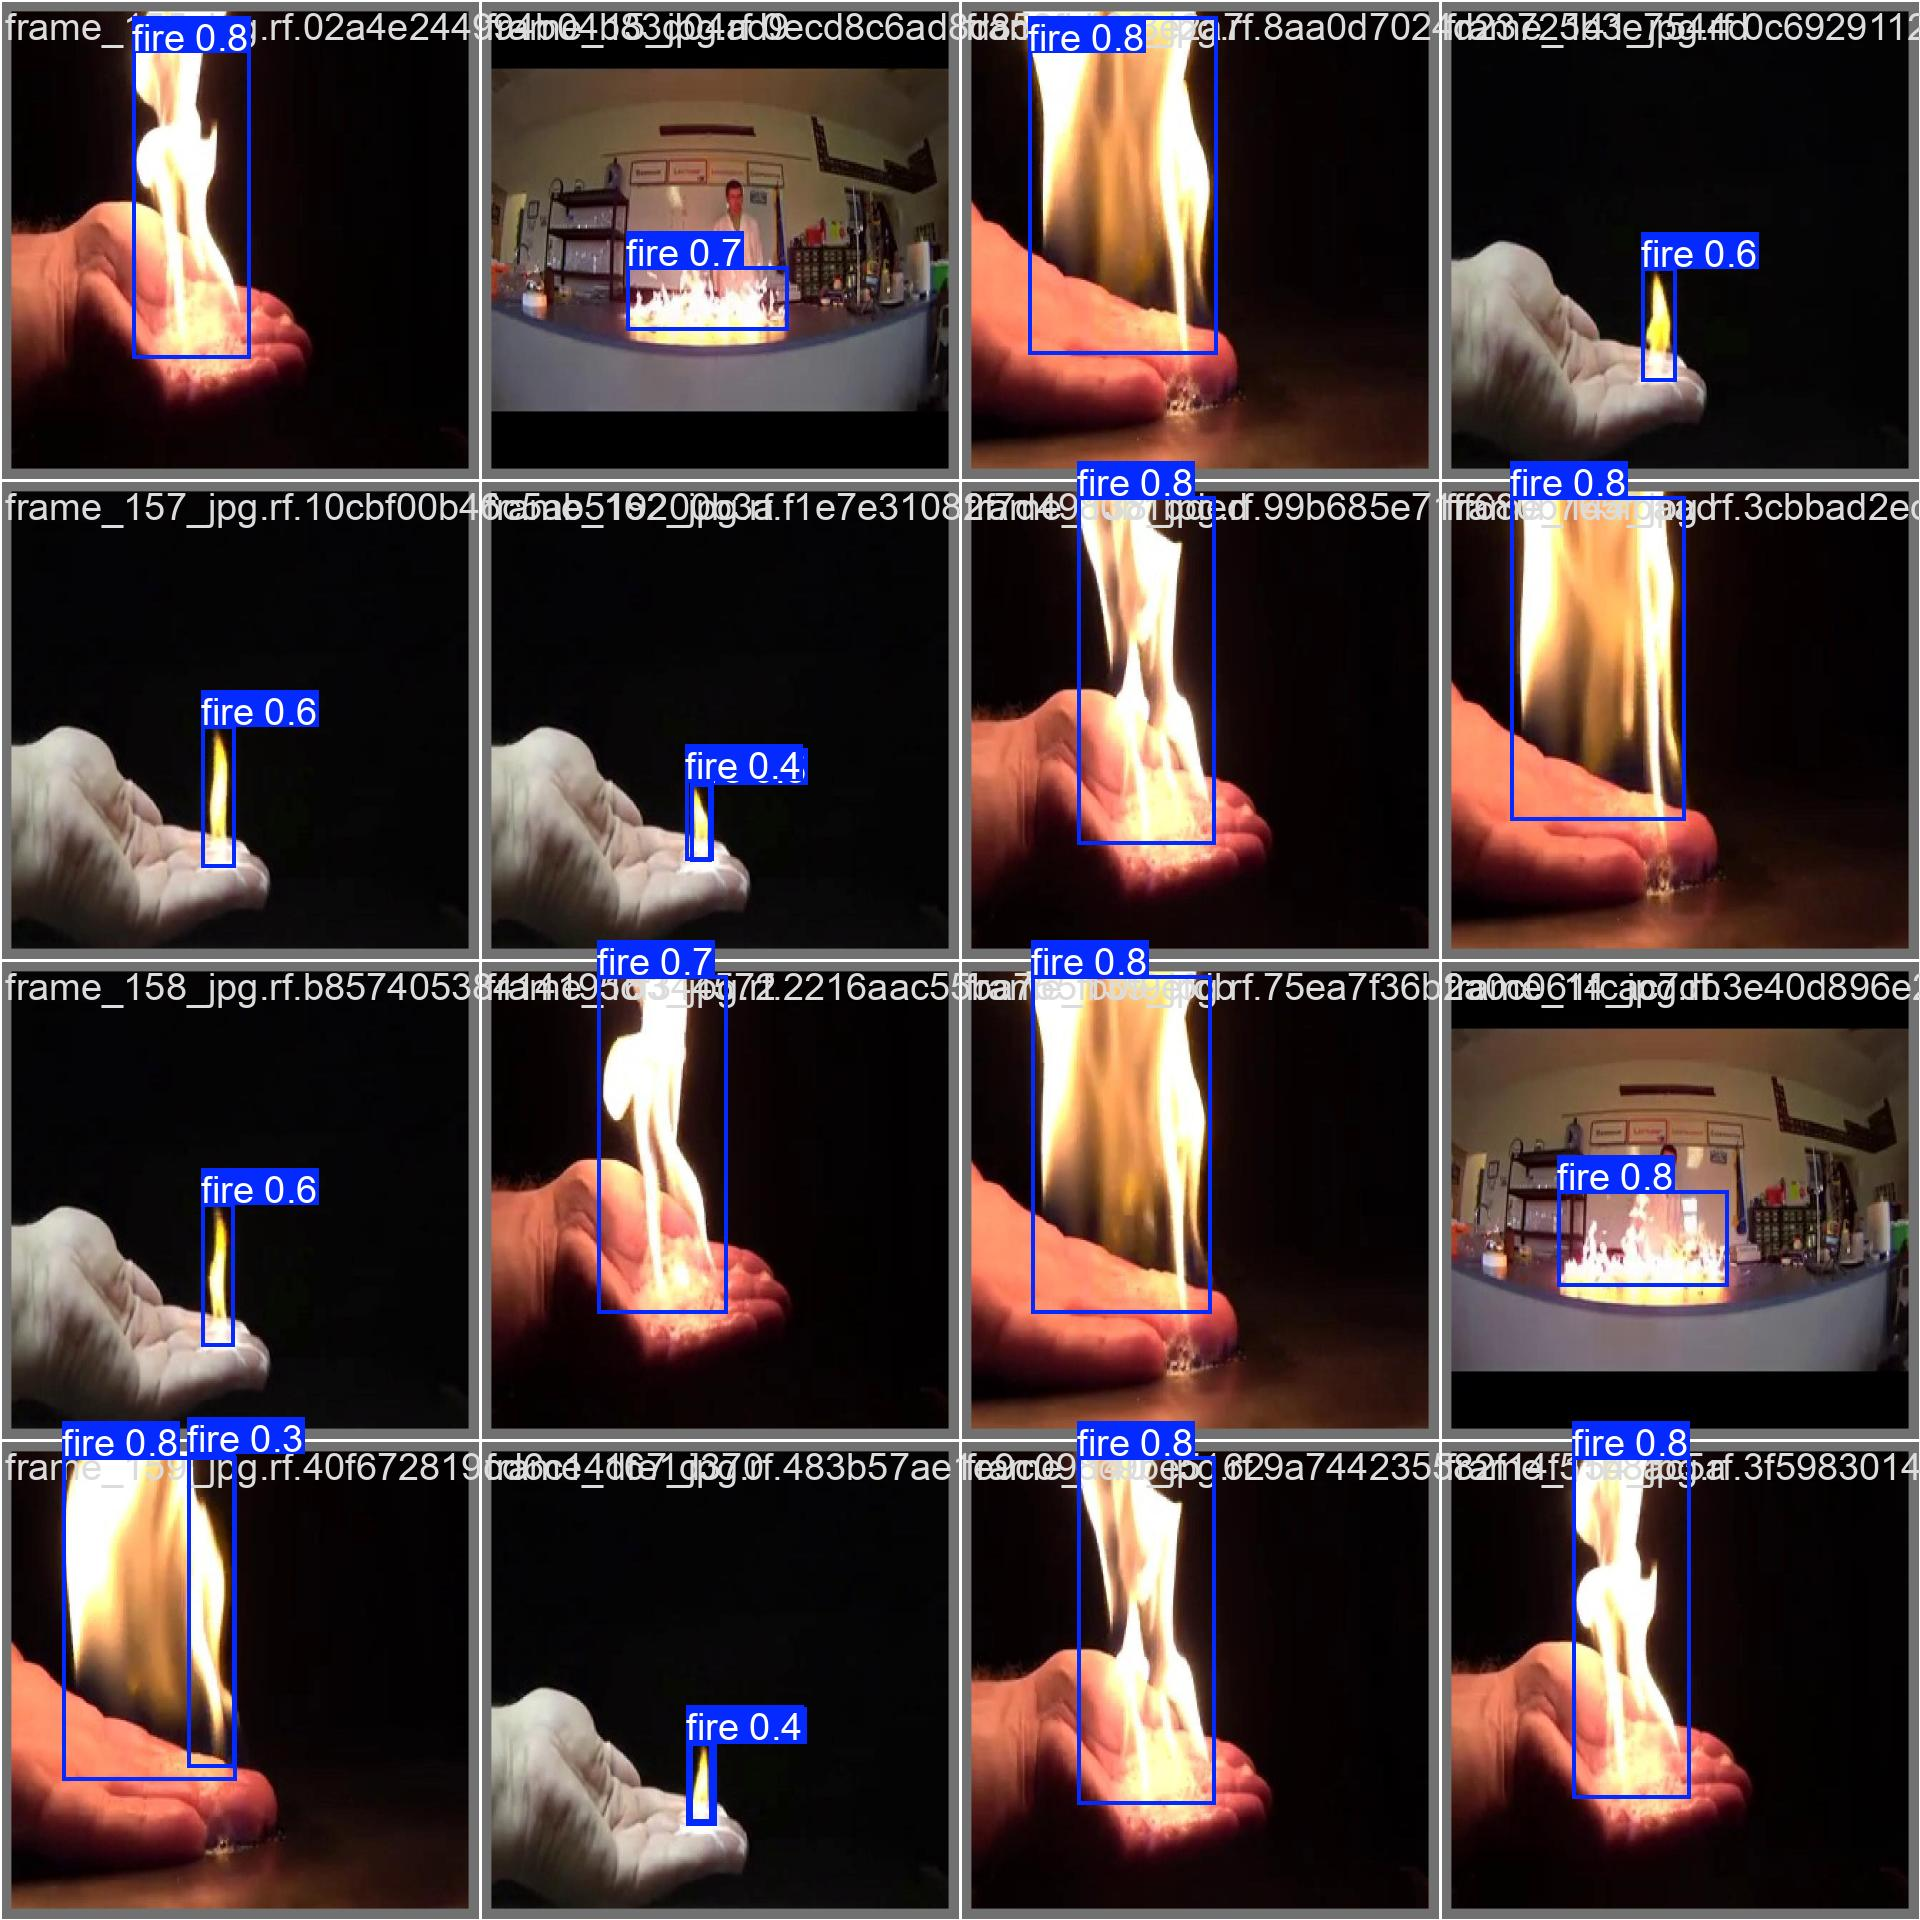

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [16]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/fire-2/valid/labels.cache... 702 images, 0 backgrounds, 0 corrupt: 100% 702/702 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/datasets/fire-2/valid/images/52_jpg.rf.50a17c320ec0dbc0d64eb24c74a1368c.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/fire-2/valid/images/Img_1039_jpg.rf.1f0fe5f5e4cd2a7f7407d551a6b532d8.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /content/datasets/fire-2/valid/images/Img_1166_jpg.rf.e943111880a6b4495ecb10f79e3e7726.jpg: 4 duplicate labels removed
val: WARNING ⚠️ /content/datasets/fire-2/valid/images/Img_1169_jpg.rf.b012f16c6367194d6fa30ff71cfdb44e.jpg: 2 duplicate labels removed
val: WARNING ⚠️ /content/datasets/fire-2/valid/images/Img_1188_jpg.rf.ca265a861e504247e2b9efbd494952fc.jpg: 2 duplicate labels removed
val: WARNING ⚠️ /content/datasets/f

## Inference with custom model

In [17]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/347 /content/datasets/fire-2/test/images/0072_JPG_jpg.rf.20f5b46815080c492db73508a9d44665.jpg: 640x640 2 fires, 17.0ms
image 2/347 /content/datasets/fire-2/test/images/0085_jpg.rf.39a3578200c6577a13e76388de03287b.jpg: 640x640 2 fires, 15.6ms
image 3/347 /content/datasets/fire-2/test/images/0090_jpg.rf.73e38228897748416937105738a1a6a6.jpg: 640x640 1 fire, 15.6ms
image 4/347 /content/datasets/fire-2/test/images/00980a5f319aec67_jpg.rf.9715c5c49daba69ecbe8c5da2f53b3e2.jpg: 640x640 1 fire, 15.5ms
image 5/347 /content/datasets/fire-2/test/images/0102_jpg.rf.cf962b9ec94876a278184c47e4b11f92.jpg: 640x640 1 fire, 15.5ms
image 6/347 /content/datasets/fire-2/test/images/0103_jpg.rf.2d4b3fc5d0bee4d1430546f33e716ed7.jpg: 640x640 (no detections), 15.5ms
image 7/347 /content/datasets/fire-2/test/images/0112_JPG_jpg.rf.fc161b88

**NOTE:** Let's take a look at few results.

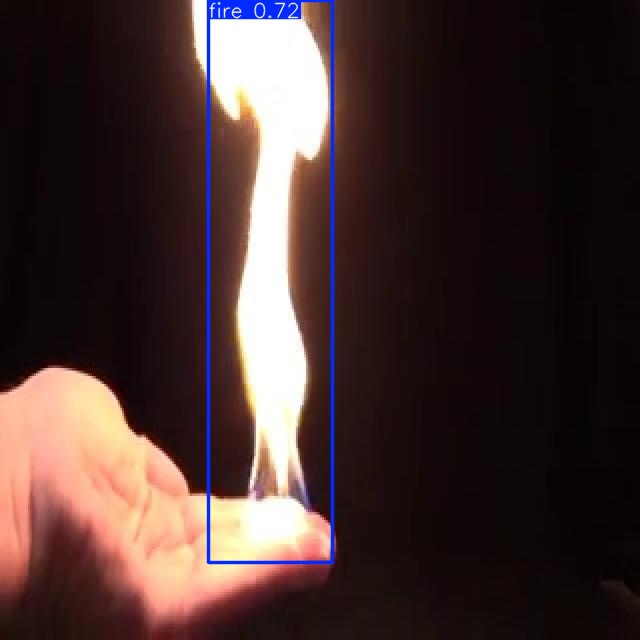

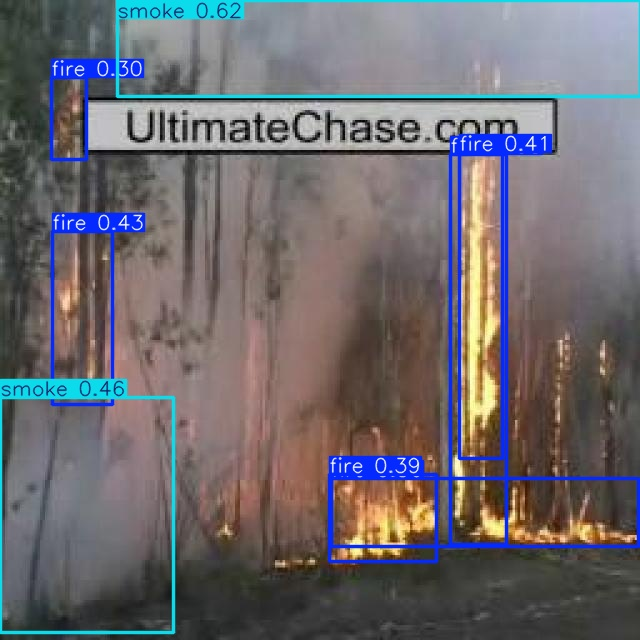

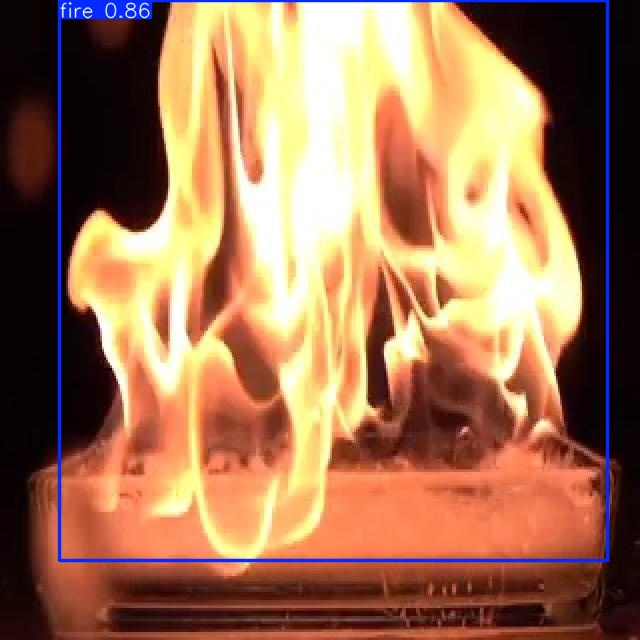

In [18]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

### Sử dụng mô hình đã huấn luyện (SDK)

Thực hiện dự đoán trên hình ảnh: /content/datasets/fire-2/test/images/Img_277_jpg.rf.b6e3aab3be4d90be82ac3bdf2388cbbe.jpg

0: 640x640 5 fires, 15.5ms
Speed: 2.0ms preprocess, 15.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


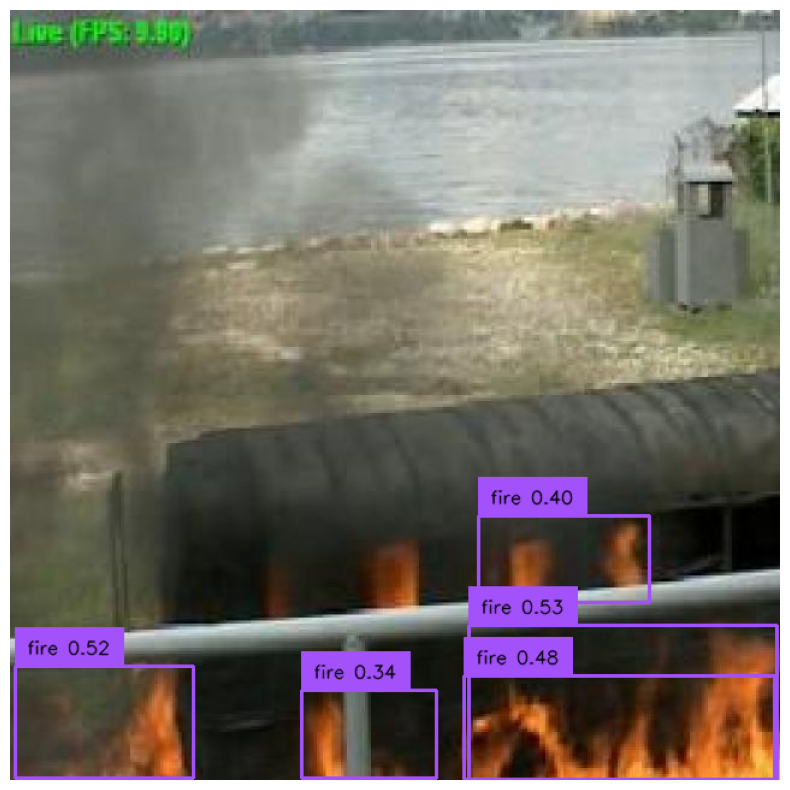

In [28]:
from ultralytics import YOLO
from PIL import Image
import random
import os

# Tải mô hình đã huấn luyện từ tệp best.pt
custom_model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

# Chọn một hình ảnh ngẫu nhiên từ tập kiểm tra để dự đoán
test_images_dir = os.path.join(dataset.location, 'test', 'images')
all_test_images = os.listdir(test_images_dir)
if all_test_images:
    random_image_name = random.choice(all_test_images)
    image_path = os.path.join(test_images_dir, random_image_name)
    print(f"Thực hiện dự đoán trên hình ảnh: {image_path}")
    image = Image.open(image_path)

    # Thực hiện dự đoán
    results = custom_model.predict(image, conf=0.25)[0]

    # Hiển thị kết quả (sử dụng supervision tương tự như trước)
    import supervision as sv
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

    # Lấy tên lớp từ mô hình (quan trọng để hiển thị nhãn chính xác)
    class_names = custom_model.names

    detections = sv.Detections.from_ultralytics(results)
    # Gán tên lớp cho các detections
    detections.class_id = detections.class_id
    detections.tracker_id = None # Không có tracker ID trong dự đoán đơn

    annotated_image = image.copy()
    annotated_image = box_annotator.annotate(annotated_image, detections=detections)
    annotated_image = label_annotator.annotate(
        annotated_image,
        detections=detections,
        labels=[f"{class_names[class_id]} {confidence:.2f}" for class_id, confidence in zip(detections.class_id, detections.confidence)]
    )

    sv.plot_image(annotated_image, size=(10, 10))
else:
    print("Không tìm thấy hình ảnh nào trong thư mục kiểm tra để thực hiện dự đoán.")

**bold text**## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [23]:
# Nâng cấp thư viện roboflow lên phiên bản mới nhất
%pip install --upgrade roboflow

In [32]:
import os
from ultralytics import YOLO
from google.colab import userdata

# Lấy Project ID đầy đủ (workspace_name/project_name)
project_id_full = f"{workspace.name}/{project.name}"

# Đường dẫn đến mô hình đã huấn luyện
model_path = os.path.join(HOME, 'runs', 'detect', 'train', 'weights', 'best.pt')

# Tải mô hình YOLO đã huấn luyện
custom_model = YOLO(model_path)

# Lấy API Key từ Colab secrets (đảm bảo nó có sẵn)
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Xuất mô hình và tải lên Roboflow
# Sử dụng phương thức export của đối tượng YOLO với format='roboflow'
custom_model.export(
    format='roboflow',
    project=project_id_full,
    api_key=ROBOFLOW_API_KEY
)

print(f"Mô hình YOLOv11 đã được xuất và tải lên Roboflow cho dự án {project_id_full}.")

SyntaxError: '[31m[1mapi_key[0m' is not a valid YOLO argument. 

    Arguments received: ['yolo', '-f', '/root/.local/share/jupyter/runtime/kernel-e4b67fef-ae3f-46b5-80d1-c005d5e0b6a5.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'detect', 'segment', 'classify', 'pose', 'obb'}
                MODE (required) is one of {'predict', 'export', 'train', 'benchmark', 'val', 'track'}
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo11n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
        yolo predict model=yolo11n-seg.pt source='https://youtu.be/LNwODJX

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.